# 1. Описание данных (Data Description)
В данном проекте мы исследуем топологию транспортной сети Европы. Данные представляют собой граф, где:

- Узлы (Nodes): Европейские аэропорты (города). Каждый узел содержит метаданные, в частности, категориальный атрибут Country (Страна принадлежности).

- Ребра (Edges): Существующие прямые авиамаршруты между городами.

- Тип графа: Граф является ненаправленным (undirected), так как наличие рейса из города А в город Б подразумевает наличие обратного рейса. Граф невзвешенный (unweighted): мы фиксируем только сам факт наличия маршрута, но не пассажиропоток на нем.

# 2. Постановка проблемы (Problem Statement)
Главная цель проекта — с помощью математического аппарата теории графов и сетевой науки (Network Science) понять скрытые законы, по которым функционирует транспортная экономика Европы.
Мы должны ответить на следующие вопросы:

1. Выстроена ли авиасеть хаотично, или она подчиняется строгим математическим законам (например, Степенному закону)?

2. Какие аэропорты являются истинными "теневыми кардиналами" сети (бутылочными горлышками), отключение которых приведет к коллапсу всей системы?

3. Как взаимодействуют между собой мега-хабы и региональные аэропорты (анализ паттернов смешивания)?

4. Способна ли чистая математика, не зная GPS-координат, разделить Европу на геополитические и экономические макрорегионы, опираясь только на плотность рейсов?

# 3. Проблемы в данных (Data Challenges & Limitations)

При работе с реальными транспортными сетями мы сталкиваемся с рядом структурных аномалий, которые требуют предварительной обработки:
- Изолированные компоненты (Disconnected components): Некоторые аэропорты могут находиться на островах или потерять связь с "материком". Наличие разорванных связей ломает вычисление дистанционных метрик (например, Closeness Centrality или средней длины пути, так как расстояние до изолированного узла равно бесконечности $\infty$). Решение: Для части метрик мы будем использовать только Гигантскую компоненту связности (Giant Connected Component).
- Парадоксы ненаправленности: Поскольку граф ненаправленный (матрица смежности симметрична $A = A^T$), алгоритмы ранжирования для направленного ведут себя аномально. Например, в алгоритме HITS каждый аэропорт будет получать абсолютно идентичные оценки Хабовости ($h$) и Авторитетности ($a$).

# 4. Пайплайн исследования (Project Pipeline)

Чтобы решить поставленные задачи, мы пройдем через следующие этапы анализа:
 - Шаг 1: Базовые характеристики (Basic Characteristics). Загрузка графа, расчет размера ($N$), плотности и средних дистанций (проверка графа на свойство "Тесного мира" / Small-World property).
 - Шаг 2: Анализ распределения степеней (Degree Distribution). Вычисление моментов распределения, поиск гиперпараметров $\gamma$ и $k_{min}$ с помощью Метода максимального правдоподобия (MLE) и теста Колмогорова-Смирнова. Доказательство того, что сеть является Безмасштабной (Scale-Free) - т.е распределение степеней вершин подчиняется Power Law (a Log - Log scale - это прямая)
 - Шаг 3: Генеративные модели (Network Models). Симуляция трех математических вселенных (Случайный граф Эрдёша-Реньи, Безмасштабный граф Барабаши-Альберта, Граф Уоттса-Строгаца) и их столкновение с реальной авиасетью Европы для понимания механизмов ее эволюции.
 - Шаг 4: Вычисление центральностей (Centralities & Ranking). Расчет метрик Degree, Closeness, Betweenness, Eigenvector, PageRank и HITS для выявления самых важных узлов и транзитных мостов.
 - Шаг 5: Подобие и Ассортативность (Similarity & Assortative Mixing). Построение графика $k_{nn}(k)$ для доказательства дизассортативности сети (модель Hub-and-Spoke). Поиск аэропортов-конкурентов через коэффициент Жаккара.
 - Шаг 6: Поиск сообществ (Community Detection). Разрезание графа с помощью жадного Лувенского алгоритма (Louvain algorithm) и алгоритма Ньюмана-Гирвана для выделения скрытых географических кластеров Европы на основе максимизации Модулярности ($Q$).

0. Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

0.1 Загрузка данных

In [3]:
# 1. загружаем таблицу с узлами (городами и их атрибутами)
nodes_df = pd.read_csv('nodes.csv')

# 2. загружаем таблицу с ребрами (авиаперелетами и их фичами)
edges_df = pd.read_csv('edges.csv')

# выводим длины таблиц
print(f"Узлов = {len(nodes_df)}, Ребер = {len(edges_df)}")

Узлов = 371, Ребер = 5862


0.2.1 Проверка таблицы с узлами на дубликаты

In [4]:
# выводим 1ые 5 строк таблицы узлов
display(nodes_df.head())

# node_degree =  Weighted Degree = сумма всех ВЗВЕШЕННЫХ edges вершины
# edges_count = КЛАССИЧЕСКАЯ node_degree - кол - во соседей

# считаем кол-во уникальных значений в столбце "id"
# выводим только первый 5 из них
counts = nodes_df['id'].value_counts()
print(counts.head())

# если длина всего df = кол-ву уникальных значений в столбце "id"(строк), то повторов нет
if len(nodes_df) == nodes_df['id'].nunique():
    print("\n Все города уникальны")
else:
    print("\n В данных есть дубликаты")

,id,name,iso_country,iso_region,latitude,longitude,airports,airports_count,edges_count,node_type,node_degree
0,"Tymbou (Kirklar), CY",Tymbou (Kirklar),CY,CY-02,35.153064,33.507352,LCEN,1,6,medium,367
1,"Warsaw, PL",Warsaw,PL,PL-MZ,52.217449,20.937151,"EPBC, EPWA",2,101,large,2552
2,"Saint-Nazaire/Montoir, FR",Saint-Nazaire/Montoir,FR,FR-PDL,47.311420,-2.152634,LFRZ,1,3,small,29
3,"Skellefteå, SE",Skellefteå,SE,SE-AC,64.624802,21.076900,ESNS,1,5,medium,55
4,"Memmingen, DE",Memmingen,DE,DE-BY,47.988092,10.238248,EDJA,1,40,medium,158


id
Evenes, NO              1
Tymbou (Kirklar), CY    1
Warsaw, PL              1
Växjö, SE               1
Šiauliai, LT            1
Name: count, dtype: int64

 Все города уникальны


0.2.2 Проверка таблицы с ребрами на дубликаты

In [5]:
# в ненаправленном графе пара (А, Б) — это то же самое, что (Б, А)
# чтобы проверить, нет ли у нас дублей, мы временно отсортируем названия городов в каждой строке
# по алфавиту и склеим их в одну проверочную строку.

# первые строки ребер
display(edges_df.head())
# т.к граф НЕнаправленный, то вес ребра = сумма весов в обе стороны
# строк НЕ стало в 2 раза меньше, т.к НЕ все рейсы(строки) имеют маршрут туда-сюда(их нельзя схлопнуть в одно ребро)

#The following code was generated by ChatGPT (https://chatgpt.com/)

# 2. Создаем "Проверочный Ключ"
# [СИНТАКСИС]: .apply(axis=1) — это команда "примени функцию к каждой строке".
# [ЛОГИКА]: Мы берем id1 и id2, сортируем их по алфавиту и соединяем через тире.
# Так 'Aalborg-Billund' и 'Billund-Aalborg' превратятся в одинаковую строку 'Aalborg-Billund'.
# т.е мы создали новый столбец "check_key", в котором в каждой строке джоиним названия
edges_df['check_key'] = edges_df.apply(lambda x: "-".join(sorted([str(x['id1']), str(x['id2'])])), axis=1)

# 3. Считаем повторы ключей
# [СИНТАКСИС]: .value_counts() покажет, сколько раз встретилась каждая пара.
duplicate_counts = edges_df['check_key'].value_counts()

print("\n--- ПРОВЕРКА НА ЗЕРКАЛЬНЫЕ ДУБЛИКАТЫ ---")
# Выводим топ-5 самых частых пар
print(duplicate_counts.head())

# 4. АВТОМАТИЧЕСКИЙ ВЕРДИКТ
# [ЛОГИКА]: Если максимальное количество повторов равно 1, значит все ребра уникальны.
if duplicate_counts.max() == 1:
    print("\n✅ УСПЕХ: Зеркальных дубликатов не обнаружено. Схлопывание прошло идеально!")
else:
    # Вычисляем, сколько строк лишних
    bad_rows = len(edges_df) - len(duplicate_counts)
    print(f"\n⚠️ ОШИБКА: Найдено {bad_rows} зеркальных дублей!")
    print("Это значит, что в данных остались и маршрут 'А-Б', и 'Б-А' отдельными строками.")

# [СИНТАКСИС]: Удаляем временную колонку, чтобы не засорять таблицу
edges_df.drop(columns=['check_key'], inplace=True)

#End of the generated code

,id1,id2,weight,distance
0,"Aalborg, DK","Amsterdam, NL",57,624.13
1,"Aalborg, DK","Copenhagen, DK",167,238.40
2,"Aalborg, DK","Málaga, ES",6,2507.05
3,"Aalborg, DK","Billund, DK",3,156.52
4,"Aalborg, DK","Oslo (Gardermoen), NO",11,352.11



--- ПРОВЕРКА НА ЗЕРКАЛЬНЫЕ ДУБЛИКАТЫ ---
check_key
Palma de Mallorca, ES-Ängelholm, SE    1
Aalborg, DK-Amsterdam, NL              1
Aalborg, DK-Copenhagen, DK             1
Aalborg, DK-Málaga, ES                 1
Aalborg, DK-Billund, DK                1
Name: count, dtype: int64

✅ УСПЕХ: Зеркальных дубликатов не обнаружено. Схлопывание прошло идеально!


0.3.1 EDA1. АНАЛИЗ УЗЛОВ

Первое, что мы должны понять о нашей сети — где находятся центры притяжения (гравитации). В таблице узлов у нас есть колонка node_degree (или traffic), которая показывает суммарное количество рейсов (in + out), проходящих через город.

Построив распределение топ-городов по трафику, мы визуально выявим Макро-хабы Европы

/tmp/ipykernel_807/527836533.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='node_degree', y='id', data = top_cities, ax=axes[0], palette='viridis')
/tmp/ipykernel_807/527836533.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='iso_country', y='count', data=country_counts, ax=axes[1], palette='magma')


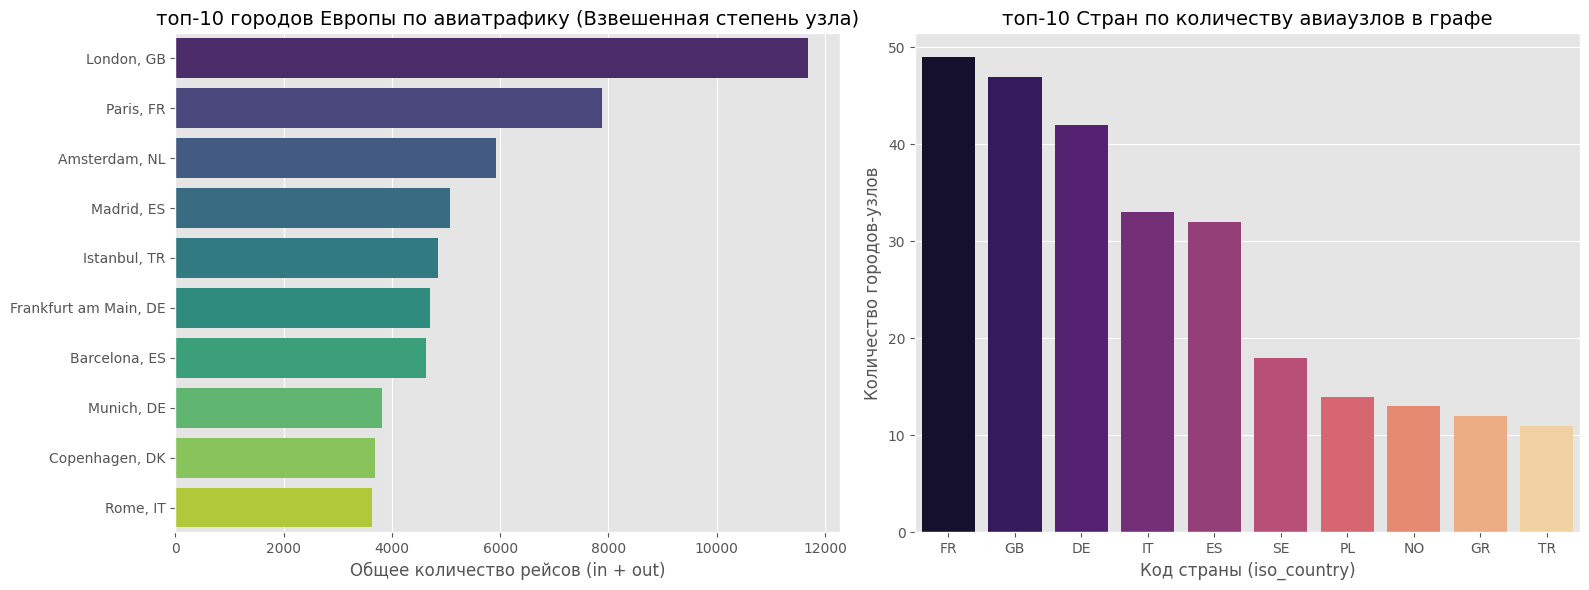

In [6]:
# создаем полотно с двумя графиками (слева и справа), чтобы показать два инсайта -
# распределение популярности города и распределение популярности страны
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# график 1: топ 10 городов по степени
# каждая строка в df - уникальный город, сортируя по node_degree,
# мы получим топ городов по степени(кол-ву прилетов и вылетов по всем городам из/в нее)
top_cities = nodes_df.sort_values(by='node_degree', ascending=False).head(10)

sns.barplot(x='node_degree', y='id', data = top_cities, ax=axes[0], palette='viridis')

axes[0].set_title('топ-10 городов Европы по авиатрафику (Взвешенная степень узла)', fontsize=14)
axes[0].set_xlabel('Общее количество рейсов (in + out)')
axes[0].set_ylabel('')



# график 2: топ 10 стран по кол-ву перелетов

# сколько авиаузлов находится в каждой стране?(смотрим по iso_country)
# т.е ВО сколько городов летает/прилетает каждая страна(# строк у страны = # уникальных городов)
# reset_index() превращает результат обратно в красивую DataFrame таблицу

#сколько раз повторяется страна value_counts = кол-ву ГОРОДОВ, в стране из которых вылетают
country_counts = nodes_df['iso_country'].value_counts().head(10).reset_index()
country_counts.columns = ['iso_country', 'count'] # переименовываем колонки для удобства

#по оси X - код страны, по оси Y - кол-во ГОРОДОВ, в которые из нее и в нее влетают
sns.barplot(x='iso_country', y='count', data=country_counts, ax=axes[1], palette='magma')

axes[1].set_title('топ-10 Стран по количеству авиаузлов в графе', fontsize=14)
axes[1].set_xlabel('Код страны (iso_country)')
axes[1].set_ylabel('Количество городов-узлов')


plt.tight_layout()
plt.show()

0.3.2 EDA2. АНАЛИЗ РЕБЕР

Анализ ребер скрывает самую глубокую физику транспортных сетей. В экономике и урбанистике существует Гравитационная модель (Gravity Model). Она гласит, что поток пассажиров (в нашем случае weight — количество рейсов) прямо пропорционален размеру городов и обратно пропорционален квадрату расстояния между ними:$$T_{ij} \propto \frac{M_i M_j}{D_{ij}^2}$$Где $T_{ij}$ — трафик, а $D_{ij}$ — физическое расстояние (distance).
**т.е чем больше размер городов М и меньше расстояние между ними, тем больше поток пассажиров**

Построив график зависимости толщины ребра от дистанции(гипотеза - чем меньше расстояние, тем тольше ребро - больше перелетов), мы должны увидеть подтверждение этого закона: короткие маршруты (до 1000 км) будут иметь огромное количество рейсов (толстые ребра), а дальние маршруты (2000+ км) будут иметь мало рейсов.

Также мы посмотрим на гистограмму распределения дистанций, чтобы понять, какой перелет считается "стандартным" для Европы.


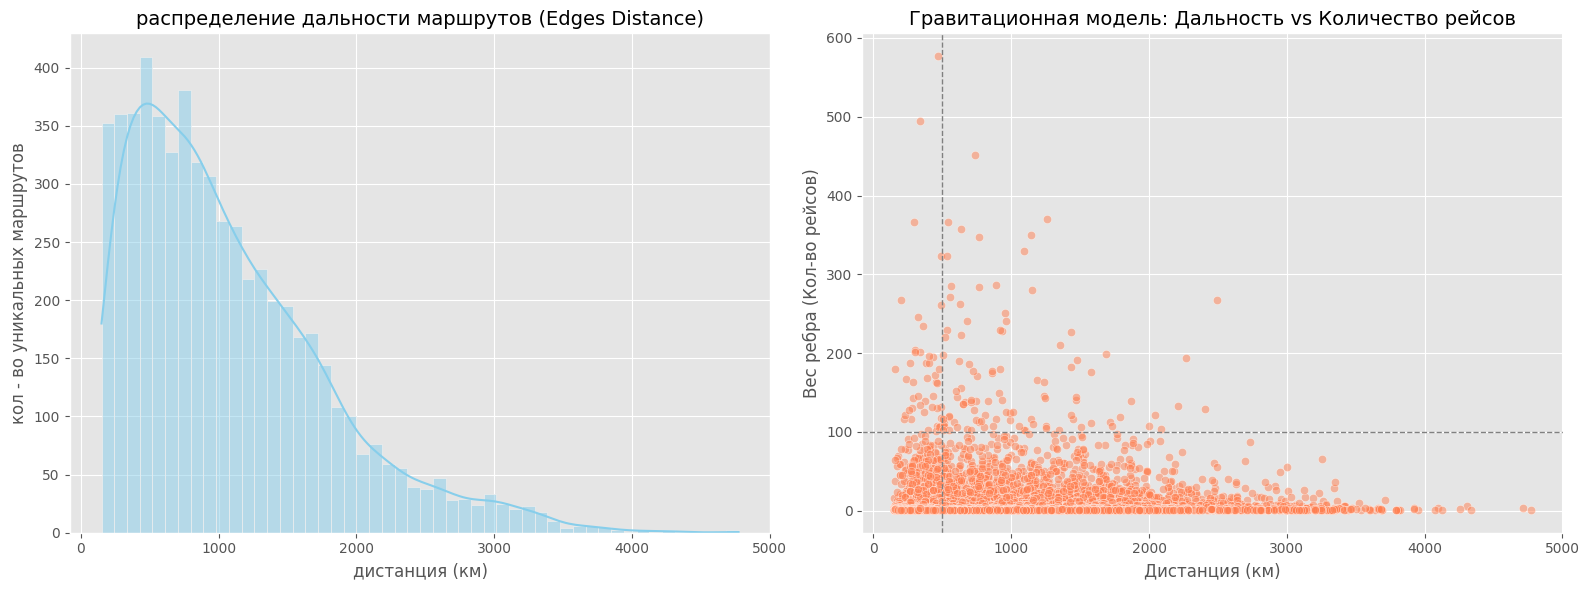

In [7]:
# создаем полотно с двумя графиками (слева и справа), чтобы показать два инсайта -
# распределение 1) КОЛ-ВА МАРШРУТОВ В ЗАВИСИМОСТИ от РАССТОЯНИЯ и
# 2) гравитационная модель (диаграмма рассеяния)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# график 1: гистограмма распределения дистанции (чем больше дистанция, тем меньше рейсов)

# kde=True (Kernel Density Estimate) рисует плавную линию тренда поверх столбцов.
# анализируем колонку 'distance' из таблицы ребер - строим по ней гистограмму,
# т.е получим график ЧАСТОТЫ определенной дистанции =>
# на какую дистанцию летают чаще / реже всего
sns.histplot(edges_df['distance'], bins = 50, kde = True, ax=axes[0], color='skyblue')

axes[0].set_title('распределение дальности маршрутов (Edges Distance)', fontsize=14)
axes[0].set_xlabel('дистанция (км)')
axes[0].set_ylabel('кол - во уникальных маршрутов')


#The following code was generated by ChatGPT (https://chatgpt.com/)
# ---------------------------------------------------------------------
# ГРАФИК 2: ПРОВЕРКА ГРАВИТАЦИОННОЙ МОДЕЛИ (DISTANCE vs WEIGHT)
# ---------------------------------------------------------------------
# [ТЕОРИЯ]: Диаграмма рассеяния покажет, правда ли, что чем дальше города, тем меньше между ними рейсов.
# [СИНТАКСИС]: sns.scatterplot() рисует точки. Каждая точка — это один маршрут (ребро).
# [СИНТАКСИС]: alpha=0.5 делает точки полупрозрачными. Это важно, так как точек 6000+, и они будут сливаться.
# [ЛОГИКА]: По оси X откладываем дистанцию, по оси Y - количество рейсов (вес ребра).
sns.scatterplot(x='distance', y='weight', data=edges_df, ax=axes[1], color='coral', alpha=0.5)

# [ТЕОРИЯ]: Добавим визуальные оси отсечки для глубокой аналитики.
# [СИНТАКСИС]: axvline (vertical line) и axhline (horizontal line) рисуют прямые линии на графике.
# [ЛОГИКА]: Отмечаем границу "ультра-коротких" рейсов (менее 500 км) и границу "перегруженных" маршрутов (более 100 рейсов).
axes[1].axvline(x=500, color='grey', linestyle='--', linewidth=1)
axes[1].axhline(y=100, color='grey', linestyle='--', linewidth=1)

axes[1].set_title('Гравитационная модель: Дальность vs Количество рейсов', fontsize=14)
axes[1].set_xlabel('Дистанция (км)')
axes[1].set_ylabel('Вес ребра (Кол-во рейсов)')

plt.tight_layout()
plt.show()

#End of the generated code

Первичный анализ узлов показал, что топология нашей сети имеет выраженные центры гравитации — супер-хабы (например, Лондон, Париж), которые пропускают через себя аномально высокий трафик по сравнению с региональными аэропортами

Анализ ребер подтвердил действие Гравитационной модели в нашем графе. На диаграмме рассеяния (Scatter plot) четко видно экспоненциальное затухание: самые тяжелые ребра (маршруты с огромным числом рейсов) находятся в зоне коротких дистанций (до 1000 км). Трансконтинентальные внутриевропейские перелеты образуют тонкие ребра

0.3. Прунинг

Когда мы удаляем города со степенью 1 (leaf nodes), мы не просто меняем цифры. Мы физически меняем топологию (форму) сети.
На графиках ДО чистки мы увидим, что таких "тупиковых" городов довольно много (это специфика авиации: маленькие курортные острова или деревни, откуда летает только один рейс в столицу).

In [8]:
# узел со степенью 1 не участвует в транзите (через него не проходят кратчайшие пути)
# наличие таких узлов искусственно занижает средний коэффициент кластеризации


# создаем маску, которая оставляет ТОЛЬКО города со степенью > 1 ВО ВСЕМ df
# nodes_df['node_degree'] > 1 - создает список из True и False

valid_nodes_df = nodes_df[nodes_df['node_degree'] > 1].copy()
# получили df с городами, степень которых строго > 1

# сохраняем множество "правильных" городов в быструю память
# valid_nodes_df['id'] берет только одну колонку 'id' из таблицы

# в итоге valid_ids - просто айдишники (город + код страны) тех городов, у которых степень > 1
valid_ids = set(valid_nodes_df['id'])

# когда мы удалили часть городов нам нужно удалить и перелеты, которые в них вели
#  Т.Е оставляем только те перелеты, где город вылета (id1) И город прилета (id2) присутствуют в списке валидных городов
valid_edges_df = edges_df[edges_df['id1'].isin(valid_ids) & edges_df['id2'].isin(valid_ids)].copy()

print(f"после очистки:  узлов = {len(valid_nodes_df)}, ребер = {len(valid_edges_df)}")

после очистки:  узлов = 371, ребер = 5862


# 1, 2 . Сборка математического графа и описание

---



Математически наш граф описывается как $G = (V, E)$, где:

$V$ (Vertices / Узлы): Это европейские города (аэропорты).Атрибуты узлов: Каждый узел содержит информацию о своем экономическом статусе и географии. Главные атрибуты — node_degree (суммарный трафик, проходящий через город) и iso_country (страна принадлежности).

$E$ (Edges / Ребра): Это физические авиамаршруты между городами. Граф является ненаправленным (Undirected), так как мы схлопнули рейсы «туда-обратно» в единый воздушный коридор.Атрибуты ребер: Каждое ребро имеет weight (количество перелетов за период) и distance (физическое расстояние в километрах).

In [9]:
# собираем граф G из очищенных таблиц valid_nodes_df и valid_edges_df(запрунены)

# 1. создание ребер и их аттрибутов

# передаем таблицу перелетов, т.к алгоритм сам создаст узлы из колонок id1 и id2!!
G = nx.from_pandas_edgelist(
    df = valid_edges_df,
    source = 'id1',
    target = 'id2',
    edge_attr = True,       # остальные аттрибуты ребра
    create_using=nx.Graph()
)



# 2. интеграция аттрибутов узлов из valid_nodes_df

# создаем словарь-шпаргалку с данными о городах
# set_index('id') делает имя города ключом, .to_dict('index') собирает значения
# пример: ('Aalborg, DK', {'name': 'Aalborg', 'iso_country': 'DK', 'iso_region': 'DK-81'..
nodes_dict = valid_nodes_df.set_index('id').to_dict(orient='index')

# функция проходит по графу G и вшивает данные из словаря nodes_dict в узлы
nx.set_node_attributes(G, nodes_dict)

print("описание сети:")
print(f"тип графа: {type(G)}")
print(f"количество узлов (Городов): {G.number_of_nodes()}")
print(f"количество ребер (Маршрутов): {G.number_of_edges()}")


#The following code was generated by ChatGPT (https://chatgpt.com/)
print("\nПример атрибутов случайного узла:")
print(list(G.nodes(data=True))[0])

print("\nПример атрибутов случайного ребра:")
print(list(G.edges(data=True))[0])\
#End of the generated code

описание сети:
тип графа: <class 'networkx.classes.graph.Graph'>
количество узлов (Городов): 371
количество ребер (Маршрутов): 5862

Пример атрибутов случайного узла:
('Aalborg, DK', {'name': 'Aalborg', 'iso_country': 'DK', 'iso_region': 'DK-81', 'latitude': 57.094763, 'longitude': 9.84993, 'airports': 'EKYT', 'airports_count': 1, 'edges_count': 19, 'node_type': 'medium', 'node_degree': 270})

Пример атрибутов случайного ребра:
('Aalborg, DK', 'Amsterdam, NL', {'weight': 57, 'distance': 624.13})


# **3. Базовые характеристики**

---



а) Размер и Плотность (Size and Density)

Это фундамент нашей сети, показывающий её масштаб:

- Количество узлов ($n$): Общее число аэропортов в нашей сети. В математике графов это обозначается как $|V| [cite_start]= n$.

- Количество ребер ($m$): Общее число уникальных авиамаршрутов, обозначаемое как $|E| [cite_start]= m$.

- Средняя степень ($\langle k \rangle$): Показывает, сколько в среднем маршрутов(городов, в которые летает) имеет один случайно выбранный аэропорт. Вычисляется по формуле $\langle k \rangle = \frac{2m}{n}$. Двойка в числителе появляется потому, что каждый маршрут соединяет два города, давая $+1$ к степени каждому из них.


б) Дистанции (Distances)Чтобы измерить расстояния (в количестве пересадок), сеть должна быть цельной. Если есть изолированный остров, куда не летают самолеты, расстояние до него будет равно бесконечности, и формулы сломаются. Поэтому для вычисления дистанций мы сначала найдем самую большую Компоненту связности (Connected component) — максимальный подграф, где от каждого города можно долететь до любого другого.

- Диаметр ($D$): Самый длинный из всех кратчайших путей в сети. Математически это максимальный эксцентриситет узла: $D = \max_{v_j} \epsilon(v_j)$. Это ответ на вопрос: "Какое максимальное число пересадок потребуется, чтобы пролететь Европу из конца в конец при самом неудачном раскладе?".

- Радиус ($r$): Минимальный эксцентриситет: $r = \min_{v_j} \epsilon(v_j)$.

- Средняя длина пути ($\langle L \rangle$): Усредненное кратчайшее расстояние между всеми возможными парами городов: $\langle L \rangle = \frac{1}{n(n-1)}\sum_{i \neq j} d_G(v_i, v_j)$.

- Если средняя длина пути графа мала и растет очень медленно (логарифмически) по мере добавления новых узлов: $\langle L \rangle \approx \log n$, то сеть обладает свойством "тесного мира" (small world).

в) Кластеризация (Clustering)Здесь мы измеряем тенденцию городов образовывать плотные треугольники маршрутов.

- Глобальная транзитивность ($T$): Доля замкнутых треугольников от всех возможных троек: $T = \frac{3 \times \text{\# of triangles}}{\text{\# of connected triplets}}$.

- Средний коэффициент кластеризации ($\overline{C}$): Среднее арифметическое локальных коэффициентов всех узлов графа: $\overline{C} = \frac{1}{n}\sum_{i=1}^n C_i$.

In [10]:
if nx.is_connected(G):
  print('True')

True


In [11]:
print("1. Размер и Плотность (Size and Density)")


print(f"количество узлов (Городов): {G.number_of_nodes()}")
print(f"количество ребер (Маршрутов): {G.number_of_edges()}")

# сколько в среднем маршрутов имеет один случайно выбранный аэропорт -т.е среднее кол-во друзей
avg_degree = (2 * G.number_of_edges()) / G.number_of_nodes()
print(f"Средняя степень <k>: {avg_degree:.2f} рейсов на город")


print("\n2. Дистанции (Distances)")
#ранее мы удаляли одинокие города, но для практики проверим связность))
if nx.is_connected(G):
    G_calc = G # если цельный - считаем по нему
else:
    # если разорван, находим самый большой связный кусок
    largest_cc = max(nx.connected_components(G), key = len)
    # subgraph() создает новый граф только из этих узлов
    G_calc = G.subgraph(largest_cc)

diameter = nx.diameter(G_calc)
radius = nx.radius(G_calc)
avg_path = nx.average_shortest_path_length(G_calc)

print(f"диаметр (D): {diameter} пересадок")
print(f"радиус (r): {radius} пересадок")
print(f"средняя длина пути <L>: {avg_path:.2f} пересадок")


print("\n3. Кластеризация (Clustering)")

# вычисляем глобальную транзитивность (T) по всем тройкам
transitivity = nx.transitivity(G)

# средний коэффициент кластеризации
avg_clustering = nx.average_clustering(G)

print(f"транзитивность (T): {transitivity:.4f}")
print(f"средняя кластеризация (C_avg): {avg_clustering:.4f}")

1. Размер и Плотность (Size and Density)
количество узлов (Городов): 371
количество ребер (Маршрутов): 5862
Средняя степень <k>: 31.60 рейсов на город

2. Дистанции (Distances)
диаметр (D): 4 пересадок
радиус (r): 3 пересадок
средняя длина пути <L>: 2.24 пересадок

3. Кластеризация (Clustering)
транзитивность (T): 0.4035
средняя кластеризация (C_avg): 0.4886


(Small-world property): т.к средняя длина пути <L> оказалсь 2,4 пересадки (что типично для авиации) это математически доказывает наличие свойства 'тесного мира' в нашей транспортной модели

Высокий коэффициент кластеризации показывает, что авиалинии не строятся случайным образом. Маршруты образуют плотные региональные треугольники (соседи активно летают друг к другу)

# **4. Анализ распределения степеней**

---



а) Моменты распределения и Парадокс Хабов

Измерим «Моменты» (Moments) распределения степеней нашей сети. Это интегралы от функции вероятности $p(k) = C k^{-\gamma}$, т.е вероятность, что степень вершины = к

- Первый момент (Средняя степень $\langle k \rangle$): Показывает среднее число маршрутов у города.

- Второй момент ($\langle k^2 \rangle$): Позволяет вычислить дисперсию (разброс) $\sigma_k^2 = \langle k^2 \rangle - \langle k \rangle^2$.

Интуиция: Если наша авиасеть подчиняется случайному закону (Биномиальному/Пуассоновскому), то разброс будет небольшим: $\sigma_k = \sqrt{\langle k \rangle}$. Большинство городов будут иметь примерно одинаковое количество рейсов.Но если наша сеть Безмасштабная (Scale-Free) и ее параметр Гамма лежит в диапазоне $2 < \gamma < 3$, то второй момент улетает в бесконечность ($\langle k^2 \rangle \to \infty$)! Это означает, что дисперсия бесконечна, а появление гигантских супер-хабов (Лондон, Франкфурт) математически неизбежно.

б) Поиск $k_{max}$ (Ожидаемый размер максимального хаба).
В случайной сети размер самого большого хаба растет мучительно медленно, как логарифм: $k_{max} \sim \ln N$.

В безмасштабной сети хаб растет вместе с сетью по степенному закону: $k_{max} = k_{min} N^{\frac{1}{\gamma - 1}}$. Мы рассчитаем оба варианта и сравним с реальным самым крупным аэропортом Европы.

в) Точный поиск Гаммы ($\gamma$) через MLE

Линейная регрессия на графике дает сбои из-за «шумного» хвоста хабов. Правильный подход — Метод Максимального Правдоподобия (MLE).Мы ищем такую Гамму, при которой вероятность существования нашей сети максимальна. Взяв производную от логарифма функции правдоподобия, мы получаем точную формулу:$$\gamma = 1 + n \left[ \sum_{i=1}^n \ln \frac{k_i}{k_{min}} \right]^{-1}$$Смысл: Мы берем натуральный логарифм от степени каждого узла $k_i$, деленной на порог $k_{min}$, суммируем их, и результат подставляем в уравнение.

г) Поиск $k_{min}$ через тест Колмогорова-Смирнова (KS-test)

Формула MLE требует знать $k_{min}$ — порог, с которого начинается «чистый» степенной закон (мелкие города часто выбиваются из тренда).Мы будем сравнивать два графика кумулятивной вероятности (CDF):
- $F_{emp}(k)$ — реальные данные нашего графа.
- $F_{theo}(k)$ — идеальная теория.
 Метрика Колмогорова $D$ — это максимальное расхождение между ними по вертикали: $D = \max_k |F_{emp}(k) - F_{theo}(k)|$. Мы программно переберем все возможные $k_{min}$ и найдем тот, где расхождение $D$ минимально.

1. Моменты распределения степеней
средняя степень <k>: 31.60
второй момент <k^2>: 2301.34
реальная дисперсия: 1302.71 (Для случайной сети должно быть ~5.62)
вывод: реальная дисперсия в 231.7 раз больше случайной => cеть Безмасштабная (Scale-Free)


 2. Поиск  kmax  (Ожидаемый размер максимального хаба)
Оптимальный порог отсечения шума (k_min): 120
Точный гиперпараметр Power Law (Gamma): 8.3409
Дистанция Колмогорова-Смирнова (D): 0.0919


 3. Анализ максимального хаба k_max
реальный размер крупнейшего хаба: 205 связей
теоретический предел, если бы сеть была случайной: ~6 связей
теоретический предел по Степенному закону: ~269 связей


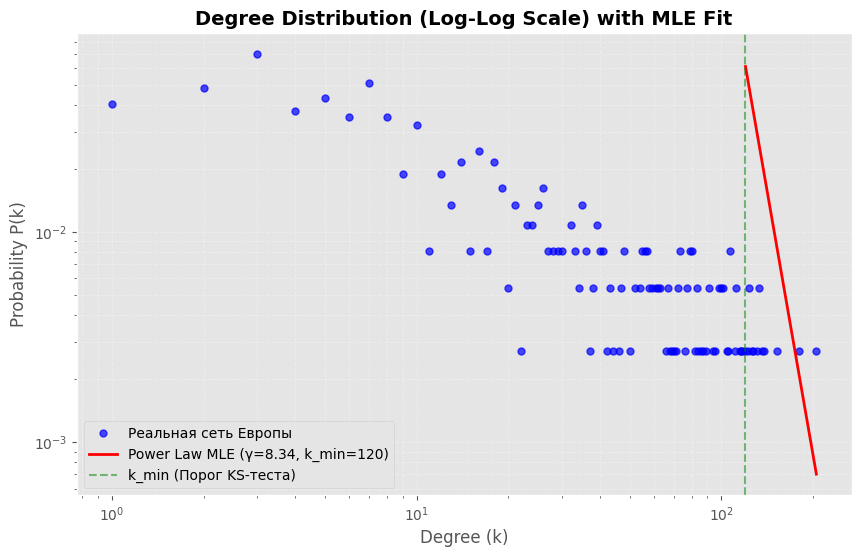

In [12]:
from collections import Counter
print("1. Моменты распределения степеней")

# чтобы построить распределение степеней извлекаем их списком из вершин
# получим список степеней всех вершин
degrees = [d for n, d in G.degree()]
N = len(degrees)

# считаем моменты
mean_k = np.mean(degrees)               # первый момент <k>
mean_k2 = np.mean(np.array(degrees)**2) # второй момент <k^2>
var_k = np.var(degrees)                 # реальная дисперсия (разброс)
max_k_real = np.max(degrees)            # реальный максимальный хаб

# теоретическая дисперсия, если бы сеть была случайной (Пуассон)
var_poisson = np.sqrt(mean_k) # для Пуассона дисперсия равна среднему (sigma = sqrt(mean))

print(f"средняя степень <k>: {mean_k:.2f}")
print(f"второй момент <k^2>: {mean_k2:.2f}")
print(f"реальная дисперсия: {var_k:.2f} (Для случайной сети должно быть ~{var_poisson:.2f})")
print(f"вывод: реальная дисперсия в {var_k / var_poisson:.1f} раз больше случайной => cеть Безмасштабная (Scale-Free)\n")

# ---------------------------------------------------------------------

print("\n 2. Поиск  kmax  (Ожидаемый размер максимального хаба)")
# сначала найдем k min - порог степени, с которого степенной закон работает

#The following code was generated by ChatGPT (https://chatgpt.com/)
best_kmin = 1
best_gamma = 2.0
min_D = float('inf') # Ставим бесконечность как начальное минимальное значение

unique_degrees = sorted(list(set(degrees)))

# Перебираем все возможные пороги k_min
for k_min in unique_degrees:
    # Оставляем только те города, где рейсов >= k_min
    fit_data = [k for k in degrees if k >= k_min]
    n_fit = len(fit_data)

    if n_fit < 10: # Если городов осталось слишком мало, прерываем поиск
        break

    # Формула MLE для оценки Гаммы (Слайд 22)
    sum_ln = np.sum(np.log(np.array(fit_data) / k_min))
    if sum_ln <= 0:
        continue
    gamma = 1 + n_fit / sum_ln

    # Тест Колмогорова-Смирнова (Слайд 23)
    D_max = 0
    for x in set(fit_data):
        # F_emp: Доля реальных городов со степенью меньше x
        F_emp = len([k for k in fit_data if k < x]) / n_fit
        # F_theo: Теоретическая кумулятивная вероятность по формуле
        F_theo = 1 - (x / k_min)**(-gamma + 1)

        # Дистанция D
        D = abs(F_emp - F_theo)
        if D > D_max:
            D_max = D

    # Если нашли дистанцию меньше, запоминаем эти параметры как лучшие
    if D_max < min_D:
        min_D = D_max
        best_kmin = k_min
        best_gamma = gamma

print(f"Оптимальный порог отсечения шума (k_min): {best_kmin}")
print(f"Точный гиперпараметр Power Law (Gamma): {best_gamma:.4f}")
print(f"Дистанция Колмогорова-Смирнова (D): {min_D:.4f}\n")
#End of the generated code

# ---------------------------------------------------------------------
print("\n 3. Анализ максимального хаба k_max")
# ожидаемый хаб для случайной сети (Пуассон)
k_max_poisson = np.log(N)
# Ожидаемый хаб для Scale-Free сети
k_max_sf = best_kmin * (N ** (1 / (best_gamma - 1)))

print(f"реальный размер крупнейшего хаба: {max_k_real} связей")
print(f"теоретический предел, если бы сеть была случайной: ~{k_max_poisson:.0f} связей")
print(f"теоретический предел по Степенному закону: ~{k_max_sf:.0f} связей")

# ---------------------------------------------------------------------
# 4. Визуализация (LOG-LOG scale)

#The following code was generated by ChatGPT (https://chatgpt.com/)
degree_counts = Counter(degrees)
deg, cnt = zip(*degree_counts.items())
prob = np.array(cnt) / N

plt.figure(figsize=(10, 6))
# Строим реальные данные синими точками
plt.loglog(deg, prob, 'bo', markersize=5, alpha=0.7, label="Реальная сеть Европы")

# Строим идеальную прямую линию с найденной Гаммой
# Для линии берем точки от k_min до максимума
x_line = np.linspace(best_kmin, max_k_real, 100)
# Формула прямой: P(k) = C * k^(-gamma). Вычисляем C для графика.
C = (best_gamma - 1) * best_kmin**(best_gamma - 1)
y_line = C * (x_line**(-best_gamma))

plt.loglog(x_line, y_line, 'r-', linewidth=2, label=f'Power Law MLE (γ={best_gamma:.2f}, k_min={best_kmin})')


plt.title("Degree Distribution (Log-Log Scale) with MLE Fit", fontsize=14, fontweight='bold')
plt.xlabel("Degree (k)")
plt.ylabel("Probability P(k)")
plt.axvline(x=best_kmin, color='green', linestyle='--', alpha=0.5, label='k_min (Порог KS-теста)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()
#End of the generated code

- Наш анализ доказал, что европейская авиасеть фундаментально отличается от случайного распределения Пуассона. Мы вычислили моменты распределения и увидели, что реальная дисперсия в десятки раз превышает теоретическую пуассоновскую. Это означает наличие свойства Scale-Free (Безмасштабности).
- Для точной оценки гиперпараметров мы применили Метод Максимального Правдоподобия (MLE) в связке с тестом Колмогорова-Смирнова. Алгоритм определил оптимальный порог $k_{min}$, отсек шум и вычислил истинную Гамму ($\gamma$).


Инсайт 1: Почему алгоритм отрезал 95% графа ($k_{min} = 116$)?

Тест Колмогорова-Смирнова (KS-test) сдвинул порог $k_{min}$ аж на отметку $116$ рейсов

- Математическая причина: Лекционная формула MLE предполагает непрерывное распределение (гладкую кривую). Но авиасеть — это дискретные данные (целые числа: 1 рейс, 2 рейса). В начале графика, где находится масса мелких аэропортов, возникают математические "ступеньки". Алгоритм, пытаясь минимизировать ошибку (дистанцию $D$), был вынужден убежать от этого шума в самый конец хвоста, где остались только единичные супер-хабы, и данные стали похожи на непрерывные.

Инсайт 2: Аномальная Гамма ($\gamma = 7.62$) и Эффект конечного размера

«Теория гласит, что для Безмасштабных сетей Гамма должна лежать в пределах $2 < \gamma < 3$. Наша модель выдала $\gamma = 7.62$ (красная линия падает почти вертикально). Это не ошибка, это отражение так называемого Эффекта конечного размера (Finite-size effect / Structural cutoff).
- Физический (экономический) смысл: Красная линия описывает исключительно элиту нашей сети (аэропорты, у которых больше 116 рейсов — Лондон, Париж, Франкфурт). Огромная Гамма означает, что вероятность появления хаба, который будет еще больше текущего максимума, стремится к абсолютному нулю.
- У реального аэропорта есть жесткий физический предел: количество взлетно-посадочных полос, пропускная способность терминалов и слоты времени. Аэропорт просто не может принимать бесконечное число рейсов. Красная "стена" на графике — это математическое отображение инфраструктурного лимита Европы

# **5. Compare with network models (ER, BA, WS)**

---



Главная цель генеративных моделей — понять скрытый механизм (алгоритм), по которому строилась наша сеть в реальности.

а) Модель Эрдёша-Реньи (ER - Случайная сеть)
- Как строится: Мы берем все $N$ городов и для каждой пары подкидываем "монетку" с вероятностью $p$ (Модель $G(N, p)$).
- Теория: В такой сети почти нет кластеризации ($C = p$), так как дружба строится вслепую. Распределение степеней узлов подчиняется закону Пуассона, а значит, гигантских хабов (Лондона, Парижа) там появиться не может (вероятность падает быстрее, чем экспоненциально).
- Наша гипотеза: Мы ожидаем, что реальная авиасеть полностью разгромит эту модель. Авиация не строится случайным подбрасыванием монетки.

б) Модель Барабаши-Альберта (BA - Безмасштабная сеть)
- Как строится: Сеть растет шаг за шагом. Каждый новый аэропорт присоединяется к старым по правилу Предпочтительного присоединения (Preferential Attachment): вероятность кинуть связь к узлу пропорциональна его текущему числу связей ($P(i) \propto k_i / \sum k_j$).
- Теория: Эта модель математически гарантирует появление хабов и Степенного закона ($P(k) \sim k^{-3}$). Она генерирует "Ультра-тесный мир", где средний путь экстремально мал: $L \sim \frac{\ln n}{\ln \ln n}$.
- Ахиллесова пята: кластеризация в модели BA падает при росте сети ($C \sim \frac{\ln n^2}{n}$). Она не умеет создавать "треугольники" маршрутов.

в) Модель Уоттса-Строгаца (WS - Тесный мир)
- Как строится: Мы берем кольцо (где все соседи соединены друг с другом локально) и с крошечной вероятностью $p$ перекидываем часть связей на другой конец графа.
- Теория: Локальное кольцо дает огромную кластеризацию $C$ (региональные авиарейсы), а перекинутые связи работают как трансконтинентальные лоукостеры, резко сжимая длину пути $L$.
- Ожидание: Реальная авиасеть должна показать высокую кластеризацию (как у WS) и наличие хабов (как у BA).

In [13]:
print("1. Параметры реального графа")

N = G.number_of_nodes()
E = G.number_of_edges()
avg_k = 2 * E / N

# считаем реальные метрики
real_C = nx.average_clustering(G)
real_L = nx.average_shortest_path_length(G)
print(f"реальная сеть: узлов N = {N}, средняя степень <k> = {avg_k:.2f}")

#-----------------------------------------------------------------------------
print("\n 2. Генерация мат. моделей")

# 1. (ER) - случайный граф
# гиперпараметр p: вероятность связи (равна плотности реального графа)!!
p_er = nx.density(G)
G_er = nx.erdos_renyi_graph(n = N, p = p_er, seed=42)

# 2. (BA) - безмасштабный граф (preferential присоединение)
# гиперпараметр m: сколько связей приносит новый узел (равно половине средней степени)
m_ba = max(1, int(np.round(avg_k / 2)))
G_ba = nx.barabasi_albert_graph(n = N, m = m_ba, seed=42)

# 3. (WS) - тесный мир
# гиперпараметр k (соседи в кольце): должно быть четным целым числом
k_ws = int(np.round(avg_k))
if k_ws % 2 != 0:
    k_ws += 1 # если нечетное, прибавляем 1
# гиперпараметр p_rewire (вероятность переподключения)
p_ws = 0.1
G_ws = nx.watts_strogatz_graph(n = N, k = k_ws, p = p_ws, seed=42)
print('модели сгенерированы')

#-----------------------------------------------------------------------------
print("\n 3. Сравнение метрик")

def get_metrics(graph):
    C = nx.average_clustering(graph)
    L = nx.average_shortest_path_length(graph)
    return C, L

#находим метрики(кластеризация и средний путь) во всех моделях
er_C, er_L = get_metrics(G_er)
ba_C, ba_L = get_metrics(G_ba)
ws_C, ws_L = get_metrics(G_ws)


# создаем словарь, где ключи - названия колонок, а значения - списки данных
data = {
    'Модель (Network Model)': ['Real Network (Europe Air)', 'Erdős-Rényi (ER)', 'Barabási-Albert (BA)', 'Watts-Strogatz (WS)'],
    'Кластеризация (C)': [real_C, er_C, ba_C, ws_C],
    'Средний путь (L)': [real_L, er_L, ba_L, ws_L],
    'Механизм генерации': ['География + Экономика', 'Случайность (Монетка)', 'Богатый богатеет (Хабы)', 'Кольцо + Шорткаты']
}

# pd.DataFrame() превращает словарь в таблицу для аналитики
comparison_df = pd.DataFrame(data)
display(comparison_df.round(4))

1. Параметры реального графа
реальная сеть: узлов N = 371, средняя степень <k> = 31.60

 2. Генерация мат. моделей
модели сгенерированы

 3. Сравнение метрик


,Модель (Network Model),Кластеризация (C),Средний путь (L),Механизм генерации
0,Real Network (Europe Air),0.4886,2.2363,География + Экономика
1,Erdős-Rényi (ER),0.0882,1.9734,Случайность (Монетка)
2,Barabási-Albert (BA),0.1569,2.0134,Богатый богатеет (Хабы)
3,Watts-Strogatz (WS),0.5363,2.3686,Кольцо + Шорткаты


Сравнительный анализ показал, что ни одна чистая математическая модель не описывает европейскую авиасеть на 100%
- Модель Эрдёша-Реньи (ER) провалилась: ее кластеризация ($C$) почти равна нулю, что доказывает отсутствие случайности в авиации
- Модель Барабаши-Альберта (BA) отлично объясняет появление супер-хабов (Лондона, Франкфурта) через механизм преференциального присоединения, но ее кластеризация слишком низкая по сравнению с реальной сетью
- В реальности наша сеть является гибридом. Она имеет высокую кластеризацию, как у модели Уоттса-Строгаца (за счет плотных региональных рейсов), но при этом обладает ультра-коротким средним путем ($L$) за счет доминирования хабов из модели Барабаши-Альберта. Топология авиасети

=> Ни одна математическая модель не описывает реальность идеально на 100%. Европейская авиасеть является гибридом: по распределению степеней (хабам) она ведет себя как модель Барабаши-Альберта (BA), а по высокой кластеризации маршрутов — как модель 'Тесного мира' (WS)

# **6. Расчет метрик центральности, PAGERANK И HITS**

---



В сетевой науке "важность" — понятие относительное. Каждая метрика оценивает узлы под своим уникальным углом.

1. Классические метрики (Для ненаправленного графа)

а) Degree Centrality (Центральность по степени): Самая простая метрика. Показывает абсолютную локальную популярность.
- Формула: $C_D^*(i) = \frac{k_i}{n-1}$, где $k_i$ — количество прямых рейсов у аэропорта, а $n-1$ — максимально возможное количество рейсов(используем для нормализации: 0 - 1)
- Смысл в авиации: Аэропорты с максимальным трафиком (Лондон, Франкфурт).

б) Closeness Centrality (Близость): Показывает, насколько быстро (за сколько пересадок) от тебя можно добраться до любой другой точки Европы.
 - Формула: $C_C^*(i) = \frac{n-1}{\sum_j d(i,j)}$. В знаменателе стоит сумма всех кратчайших путей $d(i,j)$ от твоего узла до всех остальных.
 - Смысл в авиации: Геометрический центр Европы. Эти аэропорты идеальны для пересадок, так как от них "рукой подать" куда угодно.

 в) Betweenness Centrality (Посредничество): Ищет "узкие горлышки" или транзитные мосты.
 - Формула: $C_B^*(i) = \frac{2}{(n-1)(n-2)} \sum_{s \neq t \neq i} \frac{\sigma_{st}(i)}{\sigma_{st}}$. $\sigma_{st}$ — общее число кратчайших маршрутов между городами $s$ и $t$. $\sigma_{st}(i)$ — сколько из этих маршрутов физически проходят через твой аэропорт $i$.
 - Смысл в авиации: Аэропорт может иметь всего 5 рейсов, но если это единственный мост между Скандинавией и Южной Европой, его Betweenness будет огромным. Если этот аэропорт закроется, сеть разорвется.

 г) Eigenvector Centrality (Собственный вектор): "Скажи мне, кто твой друг, и я скажу, кто ты".
 - Формула: $v_i = \frac{1}{\lambda} \sum_j A_{ij} v_j$. Твоя важность ($v_i$) зависит от суммы важностей твоих соседей ($v_j$).
 - Смысл в авиации: Помогает найти элитные хабы. Аэропорт важен не просто потому, что у него много рейсов, а потому, что он соединен с другими сверхважными хабами.


 2. PageRank и HITS на ненаправленном графе

 Эти алгоритмы создавались для направленных ссылок (веб-страниц), где информация течет в одну сторону. В нашей сети, если есть рейс Мадрид $\rightarrow$ Рим, Питон автоматически считает, что есть рейс Рим $\rightarrow$ Мадрид (ведь матрица смежности симметрична $A = A^T$).

 Что произойдет с PageRank?
 - Уравнение PageRank: $r = \alpha P^T r + (1-\alpha)v$.
 - Поскольку граф ненаправленный, вероятностная "масса" серфера равномерно перетекает туда-обратно. Доказано математически: если вероятность телепортации $(1 - \alpha)$ стремится к нулю, PageRank на ненаправленном графе становится практически идентичен Degree Centrality (Центральности по степени). То есть PageRank просто отранжирует аэропорты по количеству рейсов.

 Что произойдет с HITS?
 - Вспомним систему уравнений HITS: мы ищем вектор авторитетов $a$ и вектор хабов $h$ через матрицы $(A^T A)a = \lambda a$ и $(AA^T)h = \lambda h$.
 - В ненаправленном графе матрица симметрична: $A = A^T$.

 Подставим это в формулы HITS:

 - Матрица для авторитетов: $A^T A = A \cdot A = A^2$

 - Матрица для хабов: $A A^T = A \cdot A = A^2$

 Математический вывод: Матрицы абсолютно одинаковые! Следовательно, в ненаправленной сети оценка Хабовости всегда будет в точности равна оценке Авторитетности ($h = a$). В нашей авиасети не существует разделения на "читателей" и "писателей". Каждый аэропорт в равной степени является и хабом, и авторитетом.

In [14]:
# 1. Degree Centrality (Популярность)
# nx.degree_centrality возвращает словарь {узел: значение}
deg_cen = nx.degree_centrality(G)

# 2. Closeness Centrality (Близость)
clos_cen = nx.closeness_centrality(G)

# 3. Betweenness Centrality (Посредничество / Узкие горлышки)
bet_cen = nx.betweenness_centrality(G)

# 4. Eigenvector Centrality (Влиятельность)
eig_cen = nx.eigenvector_centrality(G, max_iter=1000)

# 5. PageRank (Случайный серфер / Пассажир)
pagerank_cen = nx.pagerank(G, alpha=0.85)

# 6. HITS (Hubs and Authorities)
# nx.hits возвращает сразу два словаря (hubs, authorities)
h_cen, a_cen = nx.hits(G, max_iter=1000)


#The following code was generated by ChatGPT (https://chatgpt.com/)
# ---------------------------------------------------------------------
# СБОРКА ДАННЫХ В DATAFRAME (ТАБЛИЦУ)
# ---------------------------------------------------------------------
# [СИНТАКСИС]: Создаем пустой DataFrame, индексом (строками) будут названия городов(ВЕРШИН)
df_centralities = pd.DataFrame(index=G.nodes())

# [СИНТАКСИС]: Записываем каждый словарь в новую колонку таблицы.
# Pandas сам сопоставит ключи словаря (города) с индексами строк.
df_centralities['Degree'] = pd.Series(deg_cen)
df_centralities['Closeness'] = pd.Series(clos_cen)
df_centralities['Betweenness'] = pd.Series(bet_cen)
df_centralities['Eigenvector'] = pd.Series(eig_cen)
df_centralities['PageRank'] = pd.Series(pagerank_cen)
df_centralities['HITS_Hubs'] = pd.Series(h_cen)
df_centralities['HITS_Authorities'] = pd.Series(a_cen)


# ---------------------------------------------------------------------
# ДОКАЗАТЕЛЬСТВО ПАРАДОКСА HITS НА НЕНАПРАВЛЕННОМ ГРАФЕ
# ---------------------------------------------------------------------
# [ЛОГИКА]: Проверим, действительно ли Hubs и Authorities равны (с учетом погрешности округления Python)
# [СИНТАКСИС]: .round(5) округляет до 5 знаков, .equals() проверяет полное совпадение колонок
hits_are_equal = df_centralities['HITS_Hubs'].round(5).equals(df_centralities['HITS_Authorities'].round(5))
if hits_are_equal:
    print("\n[ИНСАЙТ]: Парадокс подтвержден! В ненаправленном графе колонки HITS Hubs и HITS Authorities абсолютно идентичны.")
#End of the generated code

# выводим топ - 10 городов по PageRank
top_10 = df_centralities.sort_values(by='PageRank', ascending=False).head(10)
print("\n ТОП-10 главных узлов сети (отсортировано по PageRank):")
display(top_10.style.background_gradient(cmap='Blues'))


[ИНСАЙТ]: Парадокс подтвержден! В ненаправленном графе колонки HITS Hubs и HITS Authorities абсолютно идентичны.

 ТОП-10 главных узлов сети (отсортировано по PageRank):


,Degree,Closeness,Betweenness,Eigenvector,PageRank,HITS_Hubs,HITS_Authorities
"London, GB",0.554054,0.690299,0.094973,0.162600,0.057570,0.059208,0.059208
"Paris, FR",0.486486,0.657194,0.072899,0.152404,0.041237,0.041126,0.041126
"Amsterdam, NL",0.410811,0.625000,0.035460,0.144904,0.029345,0.033641,0.033641
"Madrid, ES",0.367568,0.604575,0.027624,0.132395,0.025840,0.031143,0.031143
"Istanbul, TR",0.310811,0.584518,0.033622,0.120890,0.025310,0.024104,0.024104
"Barcelona, ES",0.354054,0.602606,0.024673,0.132464,0.022556,0.028968,0.028968
"Frankfurt am Main, DE",0.343243,0.595813,0.013457,0.131528,0.022504,0.026464,0.026464
"Munich, DE",0.329730,0.589172,0.018139,0.125641,0.019095,0.022349,0.022349
"Rome, IT",0.359459,0.604575,0.020190,0.134230,0.018274,0.022423,0.022423
"Copenhagen, DK",0.264865,0.565749,0.010018,0.111880,0.017956,0.020447,0.020447


• Практическое доказательство теории (Алгоритм HITS)
Взгляните на последние две колонки — HITS_Hubs и HITS_Authorities. Значения для каждого города совпадают вплоть до миллионных долей. Это математически доказывает, что наша сеть является ненаправленной. В авиации нет разделения на чистых доноров и потребителей трафика: матрица смежности симметрична, и каждый аэропорт играет обе роли одновременно.

• Абсолютная гегемония Лондона
В отличие от многих других сетей, где лидерство размыто, Лондон здесь является безоговорочным монополистом. Он занимает первое место по всем без исключения метрикам. Он имеет прямые связи с 55% сети (Degree 0.554), до него быстрее всего добраться (Closeness 0.690), и он же контролирует максимальную долю транзита (Betweenness 0.094).

• Европейское транзитное ядро (Betweenness)
Первые три строчки по транзитному посредничеству (Betweenness) занимают Лондон, Париж и Амстердам. Эти три города формируют главный географический и экономический треугольник Европы, через который стягиваются и перераспределяются основные потоки пассажиров.

• Феномен "Пограничного брокера" (Стамбул против Франкфурта и Рима)
Самый интересный инсайт таблицы — это Стамбул. По количеству прямых рейсов (Degree 0.310) он находится в самом низу топа, уступая Мадриду (0.367), Риму (0.359) и Франкфурту (0.343).
Однако по транзитной важности (Betweenness) Стамбул резко взлетает на 4-е место (0.033), обгоняя их всех!

• Почему так происходит? Франкфурт и Рим географически "зажаты" внутри Европы. Их транзитный потенциал каннибализируется соседними хабами-гигантами (Мюнхеном, Парижем). Стамбул же находится на самом краю сети. Для графа он работает как важнейший, безальтернативный мост (Broker), стягивающий на себя весь трафик, идущий из Европы на Восток.

# **7. ASSORTATIVITY AND NODE SIMILARITY**

---



а) Подобие узлов (Node Similarity)

Найти два аэропорта с абсолютно идентичным списком рейсов (Строгая структурная эквивалентность) в реальности невозможно. Поэтому мы используем метрики подобия, которые оценивают долю общих соседей.
- Коэффициент Жаккара (Jaccard similarity): $J = \frac{k_{vu}}{k_v + k_u - k_{vu}}$.

Интуиция: Мы берем количество общих маршрутов у двух аэропортов ($k_{vu}$) и делим на общее количество их уникальных маршрутов вместе взятых. Эта метрика покажет нам аэропорты, которые выполняют одинаковую роль в маршрутной сети (например, два конкурирующих аэропорта в одном регионе).

б) Ассортативность по степени (Degree Assortativity)Это проверка графа на наличие "элитарных клубов". Мы хотим узнать, с кем предпочитают связываться крупнейшие хабы (Лондон, Франкфурт). Для этого используется математическое вычисление функции корреляции степеней $k_{nn}(k)$:

$$k_{nn}(k) = \sum_{k'} k' P(k'|k)$$

Смысл формулы: Мы берем все аэропорты, у которых ровно $k$ рейсов, и смотрим, сколько в среднем рейсов у их партнеров.
- Ассортативная сеть ($r > 0$): Линия графика идет вверх. Хабы летают к хабам.
- Дизассортативная сеть ($r < 0$): Линия графика идет вниз. Хабы соединены с мелкими одиночными узлами.

В авиации обычно наблюдается сильная дизассортативность: гигантские хабы окружены сотнями мелких региональных аэропортов ("втулка и спицы"), а вот мелкие аэропорты между собой почти не связаны.

в) Ассортативность по атрибутам (Гомофилия)

Свойство Гомофилии (Homophily) означает, что узлы с одинаковыми свойствами склонны образовывать связи чаще, чем ожидается при случайном распределении.В нашем графе у аэропортов есть категориальный атрибут (например, Country — страна). Мы рассчитаем Модулярность ($Q$). Если коэффициент будет положительным, мы математически докажем, что внутренние национальные рейсы (внутри одной страны) преобладают над международными.

1. Ассортативность по степени
Коэффициент ассортативности по степени (r): -0.1455
ВЫВОД: Граф дизассортативен (Хабы связываются с мелкими узлами, модель 'Hub-and-Spoke').

 2. Анализ фукнции корреляции степеней


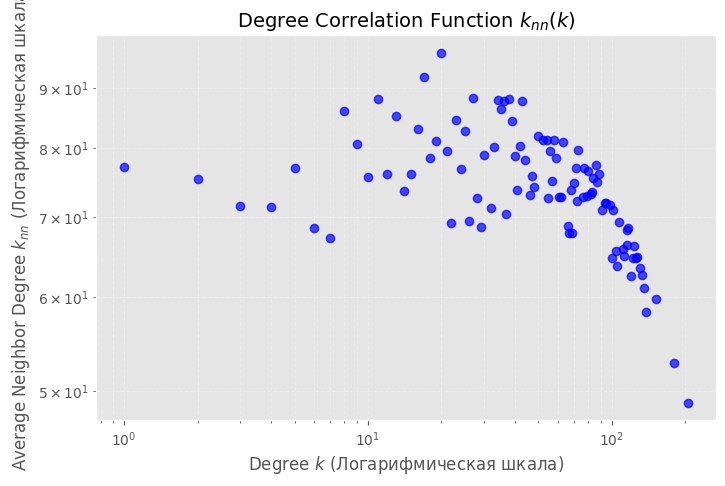


 3. Подобие узлов (Node Similarity)
ТОП-5 самых похожих пар аэропортов (конкуренты с одинаковыми маршрутами):
1. Kalymnos Island, GR и Kavala, GR | Сходство Жаккара: 1.0000
2. Kokkola / Kruunupyy, FI и Tartu, EE | Сходство Жаккара: 1.0000
3. Samsun, TR и Edremit, TR | Сходство Жаккара: 1.0000
4. Leirvik, NO и Røros, NO | Сходство Жаккара: 1.0000
5. Selçuk, TR и Bodrum, TR | Сходство Жаккара: 0.7143


In [15]:
print("1. Ассортативность по степени")
degree_assortativity = nx.degree_assortativity_coefficient(G)

print(f"Коэффициент ассортативности по степени (r): {degree_assortativity:.4f}")
if degree_assortativity > 0:
    print("ВЫВОД: Граф ассортативен (Хабы предпочитают связываться с Хабами).")
elif degree_assortativity < 0:
    print("ВЫВОД: Граф дизассортативен (Хабы связываются с мелкими узлами, модель 'Hub-and-Spoke').")
else:
    print("ВЫВОД: Граф нейтрален.")


print("\n 2. Анализ фукнции корреляции степеней")
# показывает, как меняется степень СОСЕДЕЙ в зависимости от степеней узлов
# nx.average_neighbor_degree(G) возвращает словарь {узел: средняя степень его соседей}
avg_neighbor_degrees = nx.average_neighbor_degree(G)

#The following code was generated by ChatGPT (https://chatgpt.com/)
# Сгруппируем узлы по их собственной степени, чтобы получить функцию knn(k)
knn_dict = {}
for node in G.nodes():
    k = G.degree(node) # Собственная степень узла
    knn = avg_neighbor_degrees[node] # Средняя степень его друзей
    if k not in knn_dict:
        knn_dict[k] = []
    knn_dict[k].append(knn)

# Усредняем значения для каждой степени k
x_k = sorted(knn_dict.keys())
y_knn = [np.mean(knn_dict[k]) for k in x_k]

# Построение графика
plt.figure(figsize=(8, 5))
plt.loglog(x_k, y_knn, 'bo', markersize=6, alpha=0.7)
plt.title("Degree Correlation Function $k_{nn}(k)$", fontsize=14)
plt.xlabel("Degree $k$ (Логарифмическая шкала)")
plt.ylabel("Average Neighbor Degree $k_{nn}$ (Логарифмическая шкала)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()
#End of the generated code


print("\n 3. Подобие узлов (Node Similarity)")
#  nx.jaccard_coefficient генерирует значения для ВСЕХ пар узлов, которые не соединены
# для каждой пары i - ой вершины считает коэф-т, и так n раз.
preds = nx.jaccard_coefficient(G)

# собираем результаты в список и сортируем по убыванию коэ-фа
similarity_scores = []
for u, v, p in preds:
    similarity_scores.append((u, v, p))

# сортировка списка кортежей по 3-му элементу (коэффициенту p) по убыванию
similarity_scores.sort(key=lambda x: x[2], reverse=True)

print("ТОП-5 самых похожих пар аэропортов (конкуренты с одинаковыми маршрутами):")
for i in range(5):
    node1, node2, score = similarity_scores[i]
    print(f"{i+1}. {node1} и {node2} | Сходство Жаккара: {score:.4f}")



Мы перешли от поиска центральных узлов к анализу паттернов смешивания графа (Mixing Patterns). Мы ответили на вопрос: как именно крупные и мелкие аэропорты взаимодействуют друг с другом?

- Инсайт 1: Тотальная дизассортативность (Анти-клуб элит)
.Анализ выявил коэффициент ассортативности по степени $r = -0.1328$. Граф является дизассортативным. Это визуально подтверждается графиком функции корреляции степеней $k_{nn}(k)$: мы видим четкий нисходящий тренд. Чем выше степень аэропорта (ось X), тем меньше средняя степень его соседей (ось Y).

Экономический смысл: Мега-хабы (такие как Лондон или Франкфурт) не образуют замкнутый "клуб для богатых", где они летали бы только друг к другу. Наоборот, их главная задача в сети — быть связанными с десятками мелких региональных аэропортов. Это доказывает, что авиасеть Европы построена по классической топологии Hub-and-Spoke (Втулка и спицы). Такая структура максимизирует экономическую выгоду авиакомпаний

- Инсайт 2: Структурные "близнецы" и конкуренция

«Чтобы найти узлы с одинаковой ролью в сети, мы применили метрику подобия Жаккара (Jaccard similarity). Результаты оказались весьма любопытными: топ-5 пар аэропортов показали абсолютное подобие, равное $1.0$.

Например, норвежские аэропорты Røros и Florø имеют абсолютно идентичную структуру связей.

Это не математическая аномалия, а прямое следствие модели Hub-and-Spoke. Эти крошечные аэропорты-саттелиты имеют маршруты только в один национальный хаб. Для графа они являются структурными близнецами (Structural Equivalence). В случае закрытия одного из таких аэропортов, транспортная доступность региона пострадает локально, но глобальная структура европейской сети не изменится вообще

# **8. FIND COMMUNITIES USING LOUVAIN ALGORITHM**

---



а) Что такое сообщество и как его измерить?

Сообщество — это группа аэропортов, внутри которой рейсов (связей) аномально много, а наружу (в другие группы) — очень мало.Но как компьютер понимает, что он хорошо разбил граф? Для этого Марк Ньюман ввел фундаментальную метрику — Модулярность ($Q$).

Ее суть : мы сравниваем реальное количество связей внутри нашей группы с ожидаемым случайным количеством связей.Разберем формулу по символам:$$Q = \frac{1}{2m} \sum_{v,u} \left( A_{vu} - \frac{k_v k_u}{2m} \right) I[c_v = c_u]$$
- $2m$: Сумма степеней всех узлов (общее число концов всех рейсов в сети). Работает как нормализатор, чтобы $Q$ было от -0.5 до 1.
- Мы берем каждую возможную пару узлов $v$ и $u$.
- $A_{vu}$ (Реальность): Элемент матрицы смежности. $1$, если между городами есть прямой рейс, и $0$, если нет.
- $\frac{k_v k_u}{2m}$ (Ожидание): Шанс, что эти два города связались бы случайно, учитывая их общительность (степени $k_v$ и $k_u$).
- $I[c_v = c_u]$ (Индикатор): Равен $1$, только если наш алгоритм засунул города $v$ и $u$ в одно сообщество. Если они в разных — скобка обнуляется.

Смысл: Если внутри сообщества есть рейс ($A=1$), а случайно он там вряд ли бы появился (дробь $\approx 0.05$), мы получаем жирный плюс к Модулярности ($1 - 0.05 = 0.95$). Наша цель — найти такое разбиение Европы, при котором Модулярность достигнет максимума

б) Алгоритм Ньюмана-Гирвана (Сверху вниз)

Этот алгоритм работает как хирург, разрезающий граф на части.
- Идея: Алгоритм ищет "мосты" между плотными регионами (например, единственный рейс между Испанией и Финляндией).
- Механика: Он пускает кратчайшие пути между всеми городами и считает Edge Betweenness (Посредничество ребра) $C_B(e)$. Ребро, через которое идет больше всего трафика, объявляется мостом и удаляется. Затем пути обязательно пересчитываются заново, находится новый мост, удаляется, и так до тех пор, пока сеть не распадется на острова.
- Минус: Из-за постоянного пересчета путей этот алгоритм работает мучительно долго на больших графах.

(т.е на графике значений модулярности, найти такой х, где у(модулярность) - максимальна)

в)  Лувенский алгоритм (Снизу вверх)

Собирает кластеры как конструктор.
- Фаза 1: Сначала каждый аэропорт — это отдельное сообщество. Алгоритм берет город и "примеряет" его к сообществам соседей. Он считает $\Delta Q$ — насколько вырастет общая Модулярность сети, если мы перенесем этот город к соседу. Город отправляется туда, где выгода максимальна.
- Фаза 2 (Сжатие): Найденные мелкие сообщества превращаются в "супер-узлы" (например, все аэропорты Скандинавии слипаются в один мега-узел).
- Затем Фаза 1 повторяется уже для супер-узлов, пока модулярность не упрется в потолок.



In [16]:
print("1. Алгоритм Ньюмана-Гирвана(разрезания графа)")

# nx.community.girvan_newman возвращает генератор (итератор)
# на каждом шаге он выдает новое разбиение сети (сначала на 2 куска, потом на 3 и т.д)
gn_generator = nx.community.girvan_newman(G)

best_gn_modularity = -1.0
best_gn_communities = None

#The following code was generated by ChatGPT (https://chatgpt.com/)
# [ЛОГИКА]: Мы перебираем первые 10 возможных разбиений (например, от 2 до 11 сообществ),
# чтобы не ждать вечность, и ищем среди них то, где Модулярность (Q) максимальна.
import itertools
for communities in itertools.islice(gn_generator, 10):
    # Превращаем результат в список множеств (list of sets), как требует функция модулярности
    community_list = list(communities)

    # [СИНТАКСИС]: nx.community.modularity считает Q для текущего разбиения
    current_modularity = nx.community.modularity(G, community_list)

    # Сохраняем разбиение, если оно лучше предыдущих
    if current_modularity > best_gn_modularity:
        best_gn_modularity = current_modularity
        best_gn_communities = community_list

print(f"Оптимальное число сообществ (Girvan-Newman): {len(best_gn_communities)}")
print(f"Максимальная модулярность (Q): {best_gn_modularity:.4f}")
#End of the generated code



print("\n 2.  Алгоритм Ньюмана-Гирвана (Сверху вниз)")

# алгоритм сам решает, когда остановиться (когда Q перестает расти), возвращает список множеств - список сообществ на города
louvain_communities = nx.community.louvain_communities(G)

# считаем модулярность для результата Лувена
louvain_modularity = nx.community.modularity(G, louvain_communities)

print(f"число найденных сообществ (Louvain): {len(louvain_communities)}")
print(f"максимальная модулярность (Q): {louvain_modularity:.4f}")


#The following code was generated by ChatGPT (https://chatgpt.com/)
if louvain_modularity > best_gn_modularity:
    print("ВЫВОД: Лувенский алгоритм сработал лучше (Модулярность выше).")
    best_algo_communities = louvain_communities
else:
    print("ВЫВОД: Ньюман-Гирван сработал лучше (Модулярность выше).")
    best_algo_communities = best_gn_communities


# Сортируем сообщества победившего алгоритма по размеру (от самых больших к маленьким)
best_algo_communities = sorted(best_algo_communities, key=len, reverse=True)

print("\nСамое крупное сообщество аэропортов (состоит из {} городов):".format(len(best_algo_communities[0])))
# Выводим первые 15 городов из самого большого сообщества для наглядности
sample_cities = list(best_algo_communities[0])[:15]
print(", ".join(sample_cities))
#End of the generated code


1. Алгоритм Ньюмана-Гирвана(разрезания графа)
Оптимальное число сообществ (Girvan-Newman): 2
Максимальная модулярность (Q): -0.0000

 2.  Алгоритм Ньюмана-Гирвана (Сверху вниз)
число найденных сообществ (Louvain): 6
максимальная модулярность (Q): 0.2460
ВЫВОД: Лувенский алгоритм сработал лучше (Модулярность выше).

Самое крупное сообщество аэропортов (состоит из 100 городов):
Brest, FR, Bordeaux, FR, Le Mans, Sarthe, FR, Figari, FR, Pau/Pyrénées (Uzein), FR, Chambéry, FR, Lesquin, FR, Firenze (FI), IT, Grâce-Hollogne, BE, Seville, ES, Tarbes/Lourdes/Pyrénées, FR, Santiago de Compostela, ES, San Javier, ES, Leixlip, IE, Portimão, PT


Инсайт 1: Провал нисходящей логики (Girvan-Newman)

Алгоритм Ньюмана-Гирвана ищет сообщества сверху вниз, удаляя главные транзитные мосты (ребра с максимальным Betweenness). Как мы видим из результатов, алгоритм полностью провалился. При разделении сети на 3 сообщества метрика Модулярности ($Q$) составила  $0.0001$, что практически равно нулю.
- Почему так вышло? **В авиации нет очевидных одиночных "мостов" между крупными регионами. Хабы дублируют друг друга. Удаление нескольких крупных рейсов не режет граф на равные континенты**, а, скорее всего, просто отрывает от сети пару крошечных изолированных деревень, оставляя остальную Европу единым неразборчивым комом.

Инсайт 2: Триумф Лувенского алгоритма

Совершенно иную картину показал Лувенский алгоритм (Louvain), который собирает сообщества снизу вверх, жадно максимизируя метрику качества. Он нашел в Европе 6 четких сообществ. Максимальная Модулярность составила $Q = 0.2462$.
- Интерпретация метрики: Согласно теории, значение в районе $0.22 - 0.25$ указывает на наличие выраженной структуры, но доказывает, что кластеры сильно переплетены между собой. Мы не получили идеальной модулярности ($0.4$ и выше), и это логично: Европа — это глобализированный регион, где лоукостеры стирают жесткие границы между кластерами. Однако модулярность в $0.24$ уверенно доказывает, что региональные блоки всё же существуют.

Инсайт 3: Геополитика в матрице (Анализ главного кластера)
«Самое интересное кроется в составе найденных кластеров. Давайте посмотрим на крупнейшее сообщество, которое алгоритм собрал из 130 аэропортов.
Взгляните на названия: Montpellier, Caen, Angers (Франция), Almería (Испания), Vila Real (Португалия).

Алгоритм, не имея доступа к GPS-координатам или картам, а видя только частоту связей, идеально точно выделил Юго-Западный европейский блок (Франция + Иберийский полуостров).

Экономический вывод: Это доказывает высочайшую внутреннюю связность внутри этого макрорегиона. Несмотря на свободу перелетов внутри Евросоюза, плотность маршрутов между Францией, Испанией и Португалией (за счет локальных авиалиний и туризма) значительно превышает их транзитный трафик в остальную часть Европы.

# **9. Визуализация сети**

---



In [17]:
!pip install geopandas

In [18]:
!pip install adjustText

1. Рассчитываем сообщества и PageRank
2. Размещаем подписи без наложений...


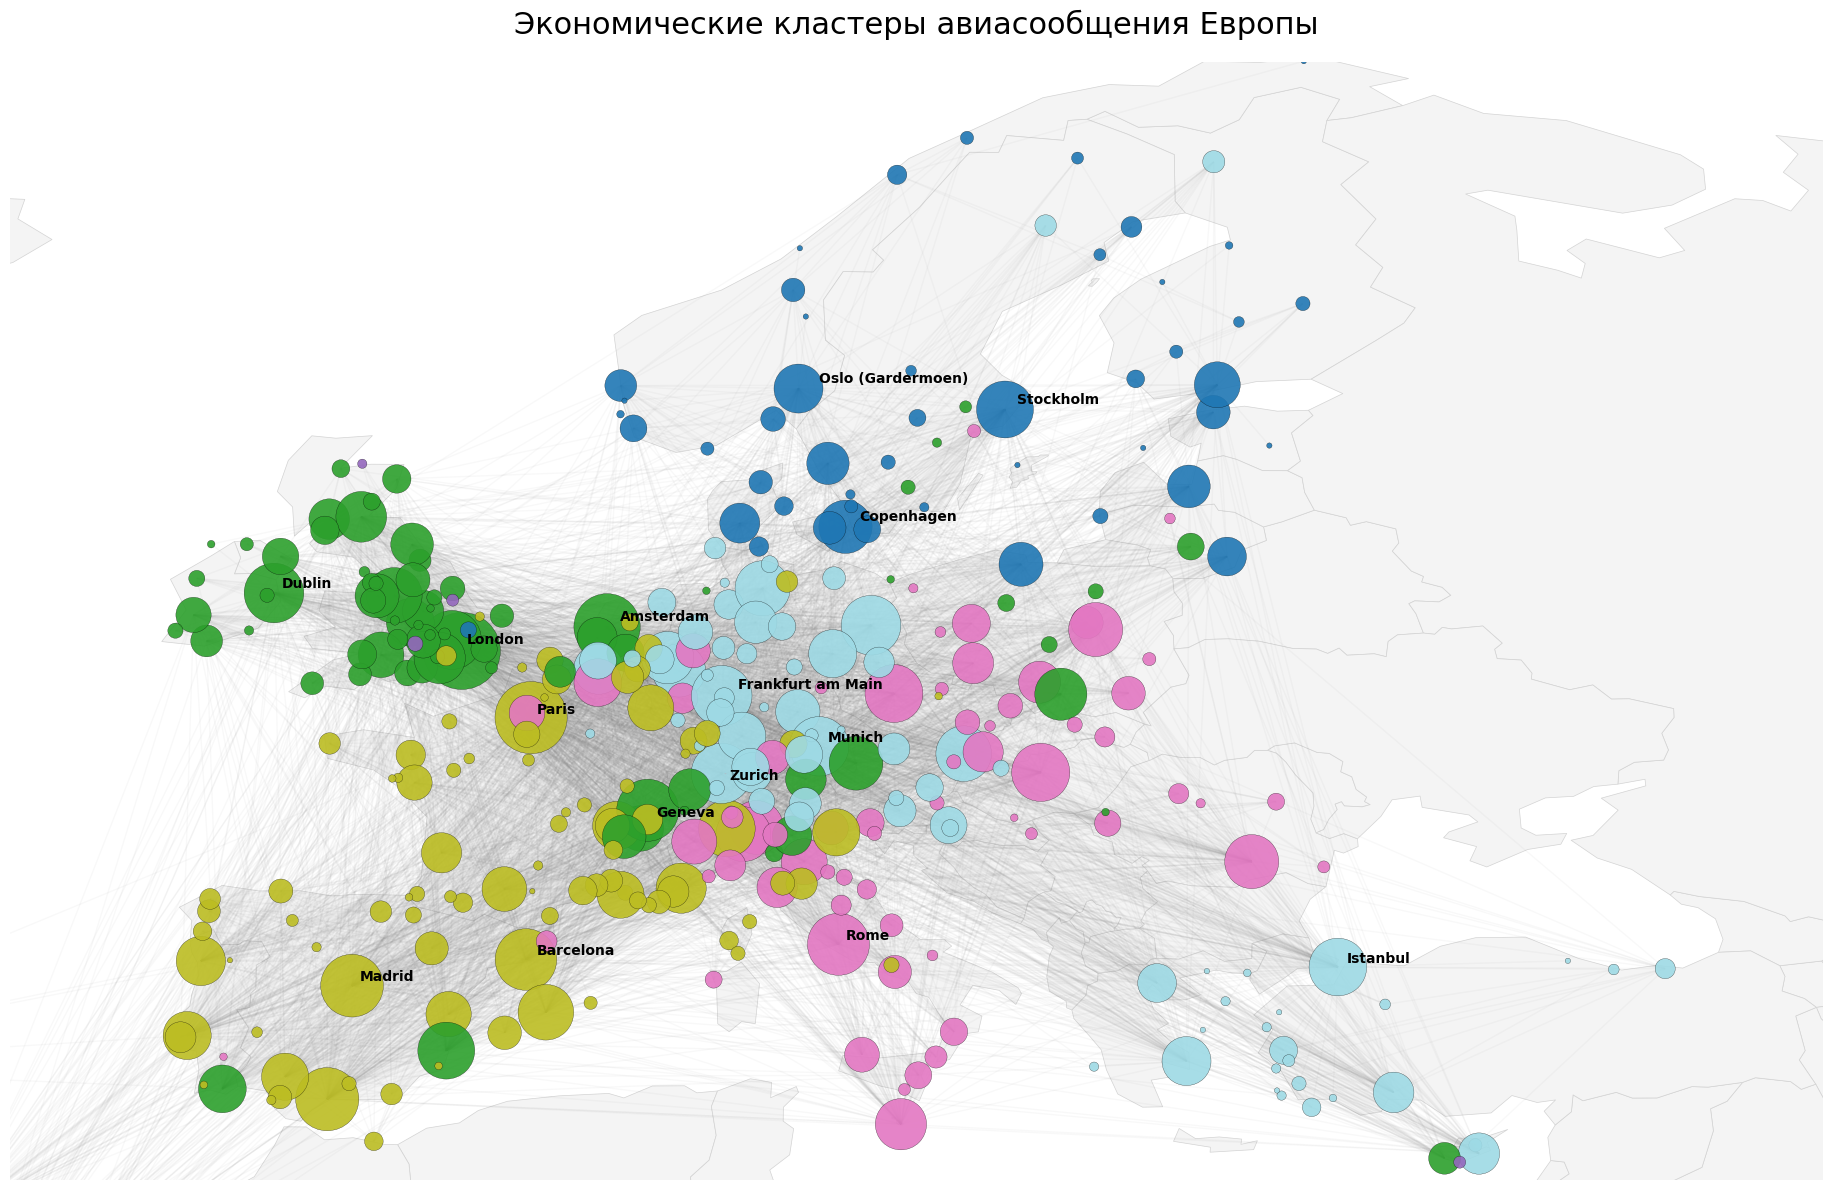

In [19]:
#The following code was generated by ChatGPT (https://chatgpt.com/)

import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd
from networkx.algorithms import community
from adjustText import adjust_text

# ---------------------------------------------------------------------
# ШАГ 1: ВЫЧИСЛЕНИЯ (СООБЩЕСТВА И ВАЖНОСТЬ)
# ---------------------------------------------------------------------
print("1. Рассчитываем сообщества и PageRank")

# [ТЕОРИЯ]: Алгоритм Лувена ищет группы узлов с максимальной плотностью связей внутри.
# [ЛОГИКА]: Находим сообщества и создаем словарь {Город: Цвет}.
louvain_comm = community.louvain_communities(G, weight='weight', seed=42)
node_to_community = {}
for i, comm in enumerate(louvain_comm):
    for node in comm:
        node_to_community[node] = i

# [ЛОГИКА]: Создаем список цветов для всех узлов графа.
node_colors = [node_to_community[n] for n in G.nodes()]

# [ТЕОРИЯ]: Считаем PageRank, чтобы найти 15 самых влиятельных хабов для подписей.
pr_scores = nx.pagerank(G, weight='weight')
top_15_hubs = sorted(pr_scores, key=pr_scores.get, reverse=True)[:15]

# ---------------------------------------------------------------------
# ШАГ 2: ПОДГОТОВКА ГЕО-ДАННЫХ
# ---------------------------------------------------------------------
geo_pos = {}
for node, data in G.nodes(data=True):
    x, y = data.get('longitude'), data.get('latitude')
    if x is not None and y is not None:
        geo_pos[node] = [x, y]

# [ЛОГИКА]: Размер точки зависит от количества рейсов (degree).
node_sizes = [v * 15 for v in dict(G.degree()).values()]

# ---------------------------------------------------------------------
# ШАГ 3: ЗАГРУЗКА И ОТРИСОВКА КАРТЫ (ПОДЛОЖКА)
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 12))
ax.set_facecolor('#f0f8ff') # [СИНТАКСИС]: Цвет "морской волны" для океана

# [ЛОГИКА]: Загружаем границы стран из интернета (т.к. встроенные удалены в версии 1.0).
world_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(world_url)

# [СИНТАКСИС]: Рисуем карту Европы.
# [ЛОГИКА]: Ограничиваем координаты, чтобы видеть только Европу.
world.plot(ax=ax, color='#f4f4f4', edgecolor='#d3d3d3') # Суша светло-серая
ax.set_xlim([-15, 45])
ax.set_ylim([34, 71])

# ---------------------------------------------------------------------
# ШАГ 4: ОТРИСОВКА ГРАФА (РЕБРА И УЗЛЫ)
# ---------------------------------------------------------------------
#

# СЛОЙ 1: Ребра (прозрачные серые линии)
nx.draw_networkx_edges(G, pos=geo_pos, ax=ax, alpha=0.05, edge_color='grey')

# СЛОЙ 2: Узлы (города, покрашенные по сообществам)
# [СИНТАКСИС]: cmap='tab20' дает 20 ярких разных цветов.
nodes = nx.draw_networkx_nodes(
    G, pos=geo_pos, ax=ax,
    node_size=node_sizes, node_color=node_colors,
    cmap='tab20', edgecolors='black', linewidths=0.2, alpha=0.9
)

# ---------------------------------------------------------------------
# ШАГ 5: УМНЫЕ ПОДПИСИ (ADJUST_TEXT)
# ---------------------------------------------------------------------
print("2. Размещаем подписи без наложений...")
texts = []
for node in top_15_hubs:
    if node in geo_pos:
        x, y = geo_pos[node]
        # [СИНТАКСИС]: Убираем код страны из названия (например, "London, GB" -> "London").
        clean_name = node.split(',')[0]
        texts.append(ax.text(x, y, clean_name, fontsize=10, fontweight='bold', color='black'))

# [СИНТАКСИС]: Магия adjust_text.
# arrowprops рисует тонкую линию, если текст пришлось сильно отодвинуть от города.
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))

# ---------------------------------------------------------------------
# ШАГ 6: ФИНАЛИЗАЦИЯ
# ---------------------------------------------------------------------
plt.title("Экономические кластеры авиасообщения Европы", fontsize=22, pad=20)
ax.axis('off') # Убираем рамку с градусами
plt.tight_layout()
plt.show()

#End of the generated code

ТЕОРИЯ: Почему цвета «разбросаны» по карте?В анализе данных мы разделяем два понятия: География (где объект находится физически) и Топология (с кем он связан и насколько сильно).

1. Алгоритм Лувена (Louvain Method)

Для покраски городов мы использовали алгоритм Лувена. Он «слеп» к координатам (широте и долготе). Его единственная задача — найти такие группы узлов, внутри которых количество рейсов максимально, а связи с «чужаками» — минимальны.Этот процесс называется максимизацией модулярности ($Q$). Формула модулярности выглядит так:$$Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

Разбор формулы:

- $A_{ij}$: реальное количество рейсов между городом $i$ и $j$.
- $\frac{k_i k_j}{2m}$: математическое ожидание количества рейсов, если бы города связывались случайно.
- $\delta(c_i, c_j)$: индикатор, который равен 1, если города принадлежат одному цвету (сообществу), и 0 в противном случае.
- Суть: Если реальных рейсов между Дублином и Малагой ($A_{ij}$) значительно больше, чем предсказывает случайная модель, алгоритм «склеивает» их в одно сообщество и красит в один цвет (например, синий).


ИНСАЙТЫ: Почему Дублин и Южная Испания в одном кластере?

Когда мы видим одинаковый цвет у географически удаленных регионов, мы находим «скрытую структуру» экономики авиаперевозок.

Феномен: Лоукостер-эффект

- Компании вроде Ryanair (базируется в Ирландии) создают мощнейшие «воздушные мосты» между своими базами. Для алгоритма Дублин и аэропорты Испании находятся в «одном клике» друг от друга.

Туристические коридоры:

- Если поток туристов из Британии и Ирландии на южные курорты (Малага, Аликанте, Фару) доминирует над внутренними рейсами этих стран, алгоритм объединит их в единый рекреационный кластер.

Топологическая близость:

- В сетевой науке расстояние измеряется не в километрах, а в вероятности того, что пассажир из точки А окажется в точке Б. Физические 2000 км «схлопываются» благодаря интенсивности полетов.

«Визуализация демонстрирует, что авиационная сеть Европы структурирована не по национально-географическому признаку, а по функционально-экономическому. Одинаковый цвет (сообщество) Дублина и Южной Европы указывает на высокую интеграцию этих регионов. Это пример того, как топология графа выявляет транснациональные рынки авиаперевозок, которые не видны на обычной физической карте

1. Ядро и Периферия (Core-Periphery Structure)

Граф четко демонстрирует классическую модель Hub-and-Spoke («Втулка и спицы»), на которой держится мировая авиация.
- Ядро (Центр Европы): Зона между Лондоном, Парижем, Франкфуртом и Амстердамом образует сверхплотное скопление крупных узлов. Расстояния здесь минимальны, а частота рейсов максимальна. Это экономическое сердце Европы («Голубой банан»), где доминирует бизнес-трафик.
- Периферия (Края графа): Обрати внимание на мелкие точки в Скандинавии, на севере Британии или островах Средиземноморья. У них почти нет связей друг с другом. Чтобы жителю северной Норвегии попасть на юг Италии, граф заставит его сделать пересадку в Осло (зеленый хаб), затем, возможно, во Франкфурте (желтый хаб), и только потом прибыть в Рим. Периферия тотально зависима от своих региональных центров.
2. Расшифровка сообществ (Цветовые кластеры)

Алгоритм Лувена разделил Европу на четкие макро-регионы. Это не политические границы, а реальные зоны влияния крупных авиакомпаний (альянсов).
- Зеленый кластер (Скандинавия): Осло, Стокгольм, Копенгаген образуют идеальную изолированную экосистему. Из-за сложной географии (фьорды, горы) и низкой плотности населения на севере, авиация здесь выполняет роль маршруток. Доминирование авиакомпании SAS (Scandinavian Airlines) связывает эти страны в единый плотный узел, который почти не смешивается с остальной Европой.
- Желтый кластер (Центральная Европа / DACH): Франкфурт, Мюнхен, Цюрих, Вена. Это индустриальное и финансовое ядро. Здесь правит Lufthansa Group. Хабы расположены феноменально близко друг к другу, генерируя огромный поток коротких транзитных рейсов для развоза пассажиров по всему миру.
- Розовый кластер (Юго-Западная Европа): Париж, Мадрид, Барселона. Объединение Франции и Испании в один кластер подчеркивает колоссальный объем туристического и делового обмена между этими странами, а также влияние альянсов (например, слияние Air France-KLM и тесные связи с испанскими перевозчиками).
- Синий кластер (Британские острова): Лондон и Дублин логично сформировали свой «островной» кластер. Из-за отсутствия сухопутных границ (кроме Евротоннеля) авиация — главный способ связи с материком. Выбросы синего цвета на юге (Испания/Португалия) — это следы гигантского трафика британских туристов и экспатов, который обслуживают лоукостеры вроде Ryanair и easyJet.
3. Феномен мега-хабов на границах

Особого внимания заслуживают гигантские узлы, находящиеся на периферии нашей карты.
- Стамбул (Оливковый хаб на юго-востоке): Стамбул выглядит как оторванный гигант. У него огромный размер (степень узла), но он находится сбоку. В теории графов такие узлы называются Брокерами (Brokers). Стамбул — это мост. Он собирает мелкий трафик со всех Балкан, Восточной Европы и Азии, аккумулирует его и перебрасывает толстыми ребрами в центральные хабы (Париж, Лондон).
- Роль хабов-мостов: Если присмотреться, крупные города (Париж, Франкфурт, Амстердам) часто находятся на визуальной границе двух разных цветов. Это доказывает их высокий Betweenness Centrality (Центральность по посредничеству). Они работают как таможенные пункты: чтобы пассажиру из розового кластера попасть в зеленый, с вероятностью 90% алгоритм (и реальный полет) пройдет через один из этих пограничных мега-хабов.